# HSC Data Retriever via Astrokit

<div align="left"> <b>Rui Zhu</b> (Peking University) </div>

creation date: 2025-08-01

## List of Content

1. [HSC Catalog Retriever](#hsc-catalog-retriever)
2. [HSC Image Retriever](#hsc-image-retriever)

In [ ]:
import astrokit as ak
from pathlib import Path
dir_test = Path('../data/example_data_HSCRetriever')

# load your HSC account
my_account = ak.datasets.my_HSC_account(
    username='your HSC username',
    password='your HSC password'
)

# initialize the HSC Retriever
hsc_ret = ak.datasets.HSCRetriever(account=my_account, dir_output=dir_test)

---
# HSC Catalog Retriever

## Submit a query

In [2]:
# write your query
sql_str = """
SELECT
        object_id
      , ra
      , dec
      , g_kronflux_mag
      , g_kronflux_magerr
      , r_kronflux_mag
      , r_kronflux_magerr
      , i_kronflux_mag
      , i_kronflux_magerr
      , z_kronflux_mag
      , z_kronflux_magerr
      , y_kronflux_mag
      , y_kronflux_magerr
    FROM
        pdr3_dud_rev.forced
        JOIN pdr3_dud_rev.forced2 USING (object_id)
    WHERE
    isprimary
    AND i_kronflux_magerr < 0.2 --- good measurement in i band Kron photometry
    AND g_kronflux_mag > 25.8 ---  gmag limit
    AND (r_kronflux_mag - i_kronflux_mag) >  0.6 --- r - i >  0.6
    AND (i_kronflux_mag - z_kronflux_mag) > -1.0 --- i - z < -1.0
    AND (i_kronflux_mag - z_kronflux_mag) < 0.52 * (r_kronflux_mag - i_kronflux_mag) - 0.412 -- i - z < 0.52(r - i) - 0.412
    AND i_kronflux_mag < 26.6 --- imag limit
    AND r_kronflux_mag < 27.5 --- rmag limit
    AND z_kronflux_mag < 25.8 --- zmag limit
    AND i_extendedness_value = 0 --- not extended
    LIMIT 10
;
"""

# submit the query
job_id = hsc_ret.submit_job(str_sql=sql_str, job_name='gband_dropouts')

[astrokit] 2025-08-01 19:51:32 | Job ID: 847186 | Submitted! | Job Name: gband_dropouts | HSC Account: zhurui_hsc_1


## Query the job status

In [3]:
job_info = hsc_ret.query_job(job_id=job_id)
print(job_info['id'])
print(job_info['status'])
print(job_info['out_format'])

847186
running
csv.gz


## Download the catalog

In [4]:
hsc_ret.get_catalog(job_id=job_id)

[astrokit] 2025-08-01 19:51:33 | Job ID: 847186 | Downloading (size: 0.001 MB) ... 
[astrokit] 2025-08-01 19:51:34 | Job ID: 847186 | File: gband_dropouts.csv.gz downloaded


In [5]:
import pandas as pd
df = pd.read_csv(dir_test / 'gband_dropouts.csv.gz')
df

,# object_id,ra,dec,g_kronflux_mag,g_kronflux_magerr,r_kronflux_mag,r_kronflux_magerr,i_kronflux_mag,i_kronflux_magerr,z_kronflux_mag,z_kronflux_magerr,y_kronflux_mag,y_kronflux_magerr
0,36429191050176614,36.323535,-6.000667,26.819778,1.047662,25.383389,0.433475,23.347115,0.092571,22.795029,0.045270,22.118774,0.121849
1,36429324194152515,36.185802,-6.094517,26.242683,0.748723,25.205475,0.409861,23.984324,0.193192,23.982416,0.279076,24.169006,0.959400
2,36429324194153519,36.303665,-6.042259,26.844624,0.854589,25.024390,0.238888,24.377851,0.188013,24.610706,0.228195,23.585540,0.366314
3,36429324194156301,36.185710,-6.098385,27.853256,2.518097,26.973658,1.577760,23.919760,0.137393,22.752449,0.069638,21.873451,0.088453
4,36429328489126829,36.133271,-5.972833,26.638134,0.561767,25.606876,0.409112,24.268913,0.180938,24.541357,0.303873,24.788786,1.198197
5,36429328489138767,36.195687,-6.019590,NaN,NaN,26.861998,0.813420,25.081390,0.197240,25.467085,0.335227,NaN,NaN
6,36429328489140241,36.267608,-5.981602,26.675780,0.264741,25.596512,0.250672,22.993420,0.025691,22.091965,0.012326,21.729946,0.026929
7,36429461633106318,36.006479,-6.085875,NaN,NaN,27.377186,1.258690,24.813099,0.198989,24.616032,0.188376,25.899757,2.332823
8,36429461633106523,36.014286,-6.078808,27.211737,0.436178,26.174173,0.283447,25.326332,0.192103,25.316040,0.205071,25.042454,0.597079
9,36429461633106683,36.112582,-6.072162,26.150040,0.510563,25.881730,0.671497,24.203196,0.198154,24.569360,0.275778,24.508970,1.101153


## Delete the job

In [6]:
hsc_ret.delete_job(job_id=job_id)

[astrokit] 2025-08-01 19:51:35 | Job ID: 847186 | File is deleted on HSC server!


---
# Get HSC Image

In [7]:
obj = df.iloc[0]
ra, dec = obj['ra'], obj['dec']
print(f"A Target - RA: {ra}, Dec: {dec}")

A Target - RA: 36.32353452282596, Dec: -6.00066670430596


In [8]:
hsc_ret.get_image(
    ra=ra, dec=dec,
    fname='test.fits', 
    bands=['g', 'r', 'i', 'z', 'y'],
    cutout_size=30,  # size of the cutout in arcsec
    img_type='coadd'
)

In [9]:
from astropy.io import fits
hdul = fits.open(dir_test / 'test.fits')
hdul.info()

Filename: ../data/example_data_HSCRetriever/test.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   ()      
  1  G_IMAGE       1 ImageHDU        31   (180, 179)   float32   
  2  G_MASK        1 ImageHDU        48   (180, 179)   int32   
  3  G_VARIANCE    1 ImageHDU        31   (180, 179)   float32   
  4  R_IMAGE       1 ImageHDU        31   (180, 179)   float32   
  5  R_MASK        1 ImageHDU        48   (180, 179)   int32   
  6  R_VARIANCE    1 ImageHDU        31   (180, 179)   float32   
  7  I_IMAGE       1 ImageHDU        31   (180, 179)   float32   
  8  I_MASK        1 ImageHDU        48   (180, 179)   int32   
  9  I_VARIANCE    1 ImageHDU        31   (180, 179)   float32   
 10  Z_IMAGE       1 ImageHDU        31   (180, 179)   float32   
 11  Z_MASK        1 ImageHDU        48   (180, 179)   int32   
 12  Z_VARIANCE    1 ImageHDU        31   (180, 179)   float32   
 13  Y_IMAGE       1 ImageHDU        31   (180, 1

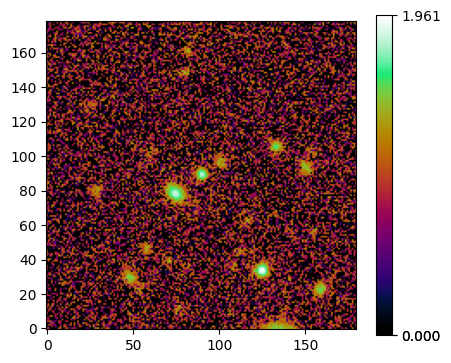

In [10]:
ak.imshow(data=hdul['i_image'].data, vmin=0)